In [51]:
import os
import sys
import glob
import json
import pickle
import datetime
import numpy as np
from copy import deepcopy
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

sys.path.insert(1, '../utils')

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

from utils import *
from mUtils import *
from plotUtils import *

%matplotlib inline
plt.rcParams.update({'font.size': 11})

In [52]:
# read parameters from a json file
with open('../params.json', 'r+') as f:
    params = json.load(f)

figureroot = "./results/system_01/lyapunov"
os.makedirs(figureroot, exist_ok=True)

In [53]:
load_dir = "../system_01/results/lyapunov/"
load_str = datetime.datetime(2024, 1, 23)
sub_dir = f"exp-{load_str.year}-{load_str.month}-{load_str.day}"

results_dir = os.path.join(load_dir, sub_dir)
file_paths = glob.glob(os.path.join(results_dir, '*.pkl'))
print(f"Total no. of files = {len(file_paths)}")

Total no. of files = 5


In [54]:
iE = 0.25 / params['gamma'] - params['i_e2']
kMin = -1; kMax = 1; kSteps = 20
kVals = kMin + np.arange(0, kSteps) / kSteps * (kMax - kMin)

sMin = 2.5; sMax = 17.5; sSteps = 20
sVals = sMin + np.arange(0, sSteps) / sSteps * (sMax - sMin)

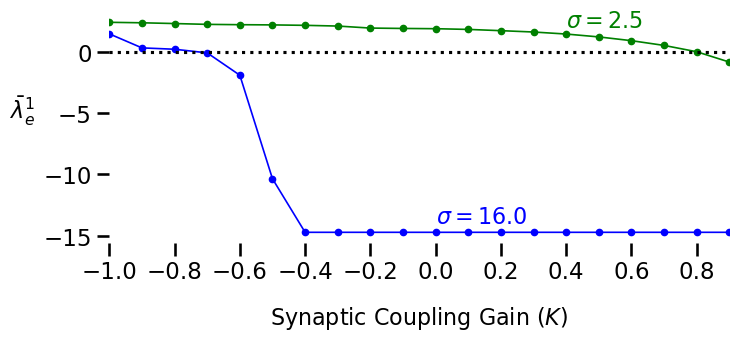

In [55]:
for path_ in file_paths:
    if f"_{iE + params['i_e2']:.3f}" not in path_:
        continue
    
    plt.figure(figsize=(8, 3))
    lyap_results = pickle.load(open(path_, 'rb'))

    lyap_results = lyap_results['n1_mean']
    minValue = min(lyap_results[lyap_results != -np.inf])
    lyap_results[lyap_results == -np.inf] = minValue
    
    lowHetLyap = lyap_results[:, 0]
    HighHetLyap = lyap_results[:, -2]
    HighHetLyap[HighHetLyap == -np.inf]  = -2.5 
    plt.plot(kVals, lowHetLyap, 'g.-', linewidth=1.2); plt.text(0.4, 2, r"$\sigma=$2.5", color='g', fontsize=16)
    plt.plot(kVals, HighHetLyap, 'b.-', linewidth=1.2); plt.text(0.0, -14, r"$\sigma=$"+f"{sVals[-2]:.1f}", color='b', fontsize=16)
    plt.axhline(y=0, color = 'k', linestyle=':')
    plt.ylabel(r"$\bar{\lambda}^1_e$", fontsize=16, rotation=0, labelpad=15)
    plt.xlabel(r"Synaptic Coupling Gain $(K)$", fontsize=16, labelpad=15)
    plt.xlim(kMin, max(kVals))
    plt.xticks(kVals[::2])
    for pos in ["right", "left", "top", "bottom"]:
        plt.gca().spines[pos].set_visible(False)
    plt.savefig(os.path.join(figureroot, f"Imod_{iE:.3f}mV_K.png"), dpi=300, bbox_inches='tight')
        

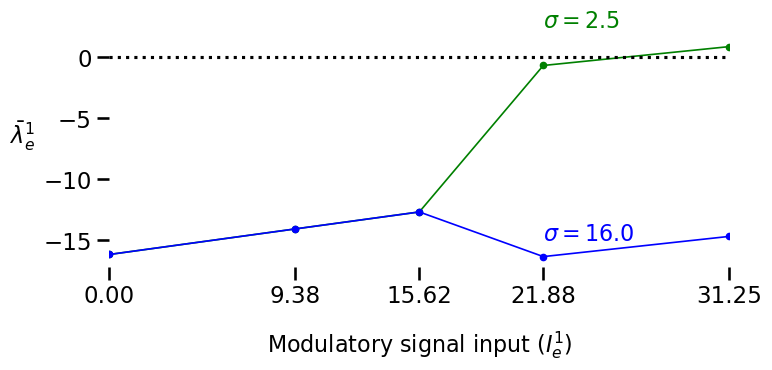

In [56]:
lowHetLyap = {}
HighHetLyap = {}

Kind = 16
for path_ in file_paths:    
    Basename = os.path.basename(path_).split('.pkl')[0]
    iE = float(Basename.split('_ie_')[-1].split('_D0_')[0]) - params['i_e2']

    lyap_results = pickle.load(open(path_, 'rb'))

    lyap_results = lyap_results['n1_mean']

    minValue = min(lyap_results[lyap_results != -np.inf])
    lyap_results[lyap_results == -np.inf] = minValue

    lowHetLyap[iE] = lyap_results[Kind, 0]
    HighHetLyap[iE] = lyap_results[Kind, -2]

iEvals = np.array(list(lowHetLyap.keys()))
iEsort = np.argsort(iEvals)
lowLyap = np.array(list(lowHetLyap.values()))
highLyap = np.array(list(HighHetLyap.values()))

lowLyap = lowLyap[iEsort]
highLyap = highLyap[iEsort]
iEvals = iEvals[iEsort]

plt.figure(figsize=(8, 3))
plt.plot(iEvals, lowLyap, 'g.-', linewidth=1.2); plt.text(21.88, 2.5, r"$\sigma=$2.5", color='g', fontsize=16)
plt.plot(iEvals, highLyap, 'b.-', linewidth=1.2); plt.text(21.88, -15, r"$\sigma=$16.0", color='b', fontsize=16)
plt.axhline(y=0, color = 'k', linestyle=':')
plt.ylabel(r"$\bar{\lambda}^1_e$", fontsize=16, rotation=0, labelpad=15)
plt.xlabel(r"Modulatory signal input $(I^1_e)$", fontsize=16, labelpad=15)
plt.xticks(iEvals)
plt.xlim(min(iEvals), max(iEvals))
for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)
plt.savefig(os.path.join(figureroot, f"K_{kVals[Kind]:.2f}_Imod.png"), dpi=300, bbox_inches='tight')

#### State transition boundary detection

In [57]:
# setting the variables
kMin = -1; kMax = 1; kSteps = 20
kVals = kMin + np.arange(0, kSteps) / kSteps * (kMax - kMin)

sMin = 2.5; sMax = 17.5; sSteps = 20
sVals = sMin + np.arange(0, sSteps) / sSteps * (sMax - sMin)

In [58]:
save_str = datetime.datetime(2023, 12, 11)
results_dict = os.path.join('../system_01/results/lyapunov/', f"exp-{save_str.year}-{save_str.month}-{save_str.day}")

file_paths = glob.glob(os.path.join(results_dict, "*.pkl"))
num_files = len(file_paths)
print(f"Number of files: {num_files}")

Number of files: 4


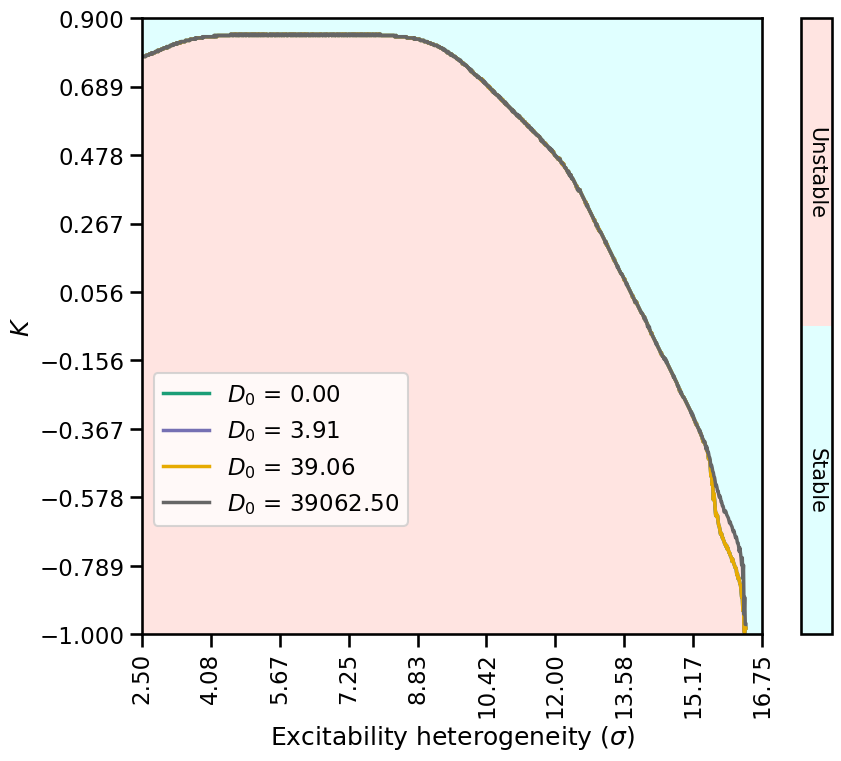

In [59]:
_D0 = []

for nf, path in enumerate(file_paths):
    basename = os.path.basename(path).split('.pkl')[0]
    D0 = float(basename.split('D0_')[-1])
    _D0.append(D0)

_D0 = np.array(_D0)

_D0sort = np.argsort(_D0)
_D0 = _D0[_D0sort]
file_paths = np.array(file_paths)[_D0sort]

colors= plt.get_cmap('Dark2')
colorIter = iter(colors(np.linspace(0, 1, len(_D0))))

plt.figure(figsize=(10,8))
for nf, path in enumerate(file_paths):
    basename = os.path.basename(path).split('.pkl')[0]
    I = float(basename.split('_D0_')[0].split('ie_')[-1])

    lyap_results = pickle.load(open(path, 'rb'))
    color = next(colorIter)

    orig_response = lyapunov_threshold(lyap_results['n1_mean'], 0.001)
    k_arr, sig_arr, response_map = lyapunov_upsample(
                                                    orig_response = orig_response, 
                                                    eval_arrx=sVals, 
                                                    eval_arry=kVals, 
                                                    y_min = kMin, y_max = max(kVals), 
                                                    x_min = sMin, x_max = max(sVals), 
                                                    sigma_x = 25, sigma_y = 25,  
                                                    resolution = 500
                                                    )
    
    edge_boundary, sig_edges, k_edges = boundary_detection(response_map, k_arr, sig_arr)

    if edge_boundary is None:
        continue

    plot_x = np.linspace(min(sig_edges), max(sig_edges), 1000)
    plot_y = edge_boundary(plot_x)

    plt.plot(plot_x, plot_y, linewidth = 2.5, label = r"$D_0$ = " + f"{_D0[nf]:.2f}", color=color)

    if _D0[nf] == _D0[-1]:
        heatmap = plt.pcolormesh(sig_arr, k_arr, response_map, cmap=ListedColormap(['lightcyan', 'mistyrose']))
        cbar = plt.colorbar(heatmap)

        cbar.ax.get_yaxis().set_ticks([])
        cbar.ax.text(0.5, .5 , r"Unstable", rotation=270, ha='center', va='center', fontsize=15)
        cbar.ax.text(0.5, -0.5 , r"Stable", rotation=270, ha='center', va='center', fontsize=15)

plt.xlabel(r"Excitability heterogeneity $(\sigma)$"); plt.ylabel(r"$K$")
plt.xticks(np.linspace(sMin, max(sVals), 10), rotation = 90); plt.yticks(np.linspace(kMin, max(kVals), 10))
plt.xlim(sMin, max(sVals)); plt.ylim(kMin, max(kVals))
plt.legend(loc = 'center left', bbox_to_anchor=(0, 0.3))
plt.savefig(os.path.join(figureroot, "boundarydetection_noise.png"), dpi = 300, bbox_inches='tight')

In [60]:
save_str = datetime.datetime(2024, 1, 23)
results_dict = os.path.join('../system_01/results/lyapunov/', f"exp-{save_str.year}-{save_str.month}-{save_str.day}")

file_paths = glob.glob(os.path.join(results_dict, "*.pkl"))
num_files = len(file_paths)
print(f"Number of files: {num_files}")

Number of files: 5


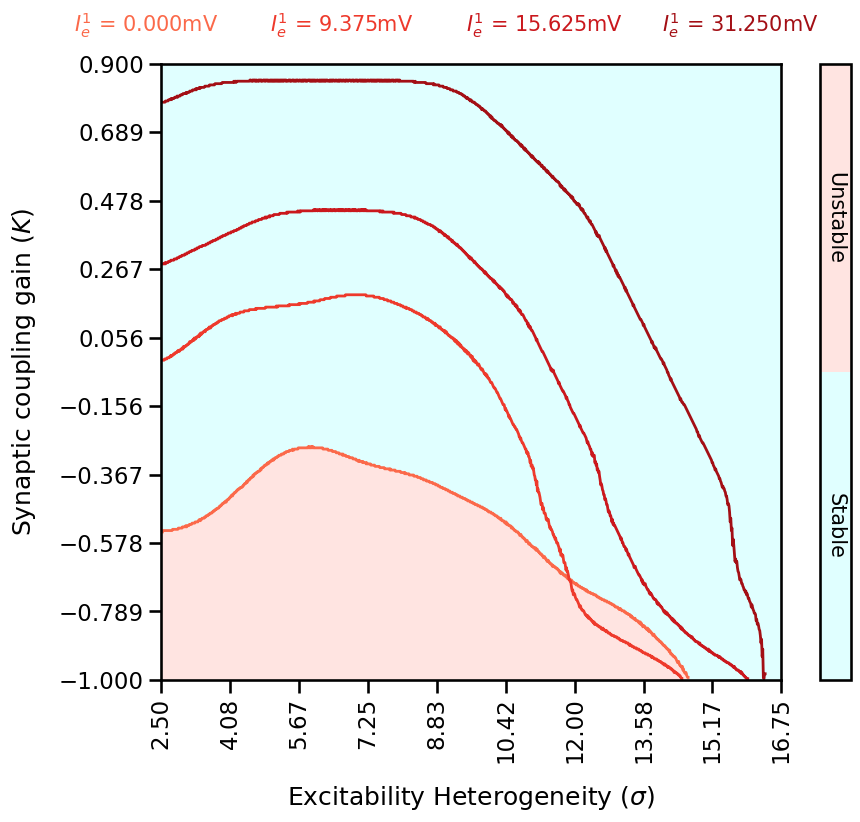

In [62]:
_I = []

for nf, path in enumerate(file_paths):
    basename = os.path.basename(path).split('.pkl')[0]
    I = float(basename.split('_ie_')[-1].split('_D0_')[0])
    _I.append(I)

_I = np.array(_I)

_Isort = np.argsort(_I)
_I = _I[_Isort]
file_paths = np.array(file_paths)[_Isort]

colors= plt.get_cmap('Reds')
colorIter = iter(colors(np.linspace(0.5, 1, len(_I))))

plt.figure(figsize=(10,8))
counter = 0
for nf, path in enumerate(file_paths):
    if nf == 3:
        continue
    basename = os.path.basename(path).split('.pkl')[0]
    color = next(colorIter)

    lyap_results = pickle.load(open(path, 'rb'))

    orig_response = lyapunov_threshold(lyap_results['n1_mean'], 0.001)
    k_arr, sig_arr, response_map = lyapunov_upsample(
                                                    orig_response=orig_response, 
                                                    eval_arrx=sVals, 
                                                    eval_arry=kVals, 
                                                    y_min = kMin, y_max = max(kVals), 
                                                    x_min = sMin, x_max = max(sVals), 
                                                    sigma_x = 25, sigma_y = 25,  
                                                    resolution = 500
                                                    )
    
    edge_boundary, sig_edges, k_edges = boundary_detection(response_map, k_arr, sig_arr)

    if edge_boundary is None:
        continue

    plot_x = np.linspace(min(sig_edges), max(sig_edges), 1000)
    plot_y = edge_boundary(plot_x)

    plt.plot(plot_x, plot_y, linewidth=2.0, c = color, label = r"$I^1_e$ = " + f"{_I[nf] - params['i_e2']:.3f}mV")
    plt.text(counter * 4.5 + 0.5, 1, r"$I^1_e$ = " + f"{_I[nf] - params['i_e2']:.3f}mV", color=color, fontsize=15)
    counter += 1

    if nf == 0:
        heatmap = plt.pcolormesh(sig_arr, k_arr, response_map, cmap=ListedColormap(['lightcyan', 'mistyrose']))
        cbar = plt.colorbar(heatmap)

        cbar.ax.get_yaxis().set_ticks([])
        cbar.ax.text(0.5, .5 , r"Unstable", rotation=270, ha='center', va='center', fontsize=15)
        cbar.ax.text(0.5, -0.5 , r"Stable", rotation=270, ha='center', va='center', fontsize=15)

plt.xlabel(r"Excitability Heterogeneity $(\sigma)$", labelpad=15); plt.ylabel(r"Synaptic coupling gain $(K)$", labelpad=15)
plt.xticks(np.linspace(sMin, max(sVals), 10), rotation = 90); plt.yticks(np.linspace(kMin, max(kVals), 10))
plt.xlim(sMin, max(sVals)); plt.ylim(kMin, max(kVals))
plt.savefig(os.path.join(figureroot, "boundarydetection_modulation.png"), dpi = 300, bbox_inches='tight')
plt.show()